# 5차시 실습 — 시각 검색 시스템 (Visual Search System)

**인공지능 플랫폼 설계 및 실습** · *이미지를 벡터로, 벡터를 가까운 순으로*

---
이 노트북은 강의(교안) **§0 ~ §6** 에 대응하는 **여섯 개의 실습**으로 이루어집니다.
각 실습은 앞 실습의 결과를 이어받으므로 **위에서부터 순서대로** 실행하세요.

| 실습 | 내용 | 대응 강의 | 예상 시간 |
|---|---|---|---|
| 실습 1 | 픽셀·채널·커널 — 이미지를 배열로 다루기 | §0 (슬라이드 8~13) | 20분 |
| 실습 2 | CNN을 직접 만들어 보기 — 쌓기·학습·임베딩 | §0 (슬라이드 14~19) | 25분 |
| 실습 3 | 사전학습 임베딩으로 유사 이미지 찾기 | §0·§3 (슬라이드 19·36) | 15분 |
| 실습 4 | 대조학습으로 임베딩 다시 배우기 | §4 (슬라이드 38~45) | 15분 |
| 실습 5 | nDCG로 채점하기 | §5 (슬라이드 48~53) | 12분 |
| 실습 6 | ANN(근사 탐색)과 재랭킹 | §6 (슬라이드 56~61) | 12분 |

> **실행 환경** · Google Colab 또는 로컬 Jupyter · **GPU 없이 CPU로 완주**할 수 있습니다.
> 데이터셋은 **CIFAR-10**(6만 장, 32×32 컬러)이며 처음 한 번 자동으로 내려받습니다.

---
> **📘 학생용(실습)** · **`#### ✍️ 직접 구현`** 표시가 있는 셀의 `...` 부분을 채우면 됩니다.
> **`· (실행만)`** 이라고 적힌 셀은 그대로 실행하세요.

## 0. 준비 — 라이브러리 · 한글 폰트 · 데이터
아래 두 셀을 **가장 먼저** 실행하세요. CIFAR-10 다운로드가 처음 한 번 시간이 걸립니다. (여기는 채울 것이 없습니다.)

TensorFlow 2.21.0
GPU 사용 가능: False (없어도 됩니다)
한글 폰트   : NanumGothic


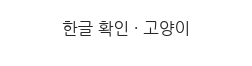

In [1]:
# ============================================================
# 0-1. 라이브러리 · 한글 폰트 · 재현성
#      (Colab · VSCode(Windows/macOS/Linux) 어디서든 실행됩니다)
# ============================================================
import warnings; warnings.filterwarnings('ignore')

import os, time, glob, shutil
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '2')   # 텐서플로 로그 줄이기

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import tensorflow as tf


def setup_korean_font():
    """OS에 맞는 한글 폰트를 찾아 matplotlib 에 등록한다 (Colab · VSCode 공통)."""
    cands = ['NanumGothic', 'NanumBarunGothic',       # Colab · 리눅스
             'Malgun Gothic',                          # Windows (맑은 고딕)
             'AppleGothic', 'Apple SD Gothic Neo']     # macOS
    have = lambda: {f.name for f in fm.fontManager.ttflist}
    for name in cands:
        if name in have():
            return name
    if shutil.which('apt-get'):                        # Colab · 리눅스에서만 설치
        os.system('apt-get -qq update')
        os.system('apt-get -qq install -y fonts-nanum')
    # 설치된 ttf 파일을 직접 등록한다 — 이 줄이 있어야 런타임 재시작 없이 바로 적용된다
    for path in glob.glob('/usr/share/fonts/**/Nanum*.ttf', recursive=True):
        fm.fontManager.addfont(path)
    for name in cands:
        if name in have():
            return name
    print('⚠️ 한글 폰트를 찾지 못했습니다 — 그래프의 한글이 □ 로 보일 수 있습니다.')
    return None


KFONT = setup_korean_font()
sns.set_theme(style='whitegrid', font=KFONT or 'sans-serif')
if KFONT:
    plt.rcParams['font.family'] = KFONT                # seaborn 테마보다 반드시 뒤에 올 것
plt.rc('axes', unicode_minus=False)                    # 마이너스 기호가 □ 로 나오는 것 방지

# 재현성: 학습에 쓰이는 무작위(가중치 초기화·증강)를 고정한다
tf.keras.utils.set_random_seed(42)

print('TensorFlow', tf.__version__)
print('GPU 사용 가능:', bool(tf.config.list_physical_devices('GPU')), '(없어도 됩니다)')
print('한글 폰트   :', KFONT)
plt.figure(figsize=(3, 0.6))
plt.text(.5, .5, '한글 확인 · 고양이', ha='center'); plt.axis('off'); plt.show()

In [2]:
# ============================================================
# 0-2. 데이터 — CIFAR-10 불러오기
# ============================================================
# 실습에 쓰는 테스트셋 앞 7,000장(검색 DB 2,000 + 학습 5,000)만 담은 작은 파일을 먼저 찾는다
#   ① 노트북 폴더의 cifar10_test7000.npz → ② 교수자 GitHub → ③ 원본 CIFAR-10 전체(약 170MB, 받은 뒤 ① 파일을 자동 생성)
N_USE       = 7000                                              # x_test[:2000] = DB, x_test[2000:7000] = 학습용
SUBSET_FILE = 'cifar10_test7000.npz'
SUBSET_URL  = 'https://joy-bae.github.io/cifar10_test7000.npz'   # 교수자가 올려 둔 위치


def load_cifar_test_head(n=N_USE):
    for where, src in [('로컬 파일', SUBSET_FILE), ('교수자 GitHub', SUBSET_URL)]:
        try:
            if where == '로컬 파일':
                if not os.path.exists(src):
                    continue
                path = src
            else:
                path = tf.keras.utils.get_file(SUBSET_FILE, src)    # 받은 파일은 ~/.keras/datasets/ 에 남는다
            d = np.load(path)
            if len(d['x_test']) >= n:
                print(f'✅ {where} 사용 ({n}장)')
                return d['x_test'][:n], d['y_test'][:n]
            print(f'⚠️ {where}의 이미지 수가 {n}장보다 적어 사용하지 않습니다.')
        except Exception as e:
            print(f'   {where}를 쓸 수 없음 ({type(e).__name__}) → 다음 방법으로')

    (_, _), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()   # 처음 한 번 다운로드
    x_test, y_test = x_test[:n], y_test.ravel()[:n]
    np.savez_compressed(SUBSET_FILE, x_test=x_test, y_test=y_test)
    print(f"✅ 원본 CIFAR-10에서 앞 {n}장만 골라 '{SUBSET_FILE}' 로 저장했습니다 (다음 실행부터 이 파일 사용).")
    return x_test, y_test


x_test, y_test = load_cifar_test_head()
CLASS = ['비행기','자동차','새','고양이','사슴','개','개구리','말','배','트럭']

# ── 검색 대상 DB와 질의를 '고정 인덱스'로 정한다 (랜덤 추출 없음) ──
X_db  = x_test[:2000]          # 검색 대상 = 우리 서비스에 저장된 이미지 2000장
y_db  = y_test[:2000]
QUERIES = [7, 12, 25, 44]      # 항상 이 4장을 질의로 쓴다 (누가 실행해도 동일)

print('검색 DB :', X_db.shape, '· 질의 인덱스 :', QUERIES)
for q in QUERIES:
    print(f'  질의 {q:>3d} → {CLASS[y_db[q]]}')

19761289/19761289 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ 교수자 GitHub 사용 (7000장)
검색 DB : (2000, 32, 32, 3) · 질의 인덱스 : [7, 12, 25, 44]
  질의   7 → 개구리
  질의  12 → 개
  질의  25 → 새
  질의  44 → 비행기


---
# 실습 1 — 픽셀·채널·커널

> **강의 대응** §0 슬라이드 8~13
> **목표** 이미지가 (H, W, C) 숫자 배열임을 눈으로 확인하고, 픽셀 거리의 한계를 직접 재고, 커널(필터)이 특성맵을 만드는 과정을 손으로 구현한다.

### 1-1. 이미지를 배열로 열기 — 컴퓨터는 무엇을 보는가  *(슬라이드 8)*  · (실행만)

shape : (32, 32, 3)   ← (H, W, C) = (높이, 너비, 채널)
dtype : uint8 · 최솟값/최댓값 : 9 / 255
숫자 개수 : 3072 개  (= 32 × 32 × 3)


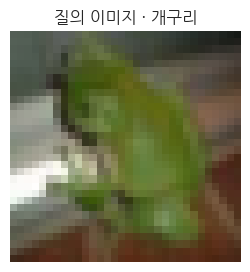

In [4]:
img = X_db[7]      # 질의 이미지 한 장 (고정)

print('shape :', img.shape, '  ← (H, W, C) = (높이, 너비, 채널)')
print('dtype :', img.dtype, '· 최솟값/최댓값 :', img.min(), '/', img.max())
print('숫자 개수 :', img.size, '개  (= 32 × 32 × 3)')

plt.figure(figsize=(3,3))
plt.imshow(img); plt.title(f'질의 이미지 · {CLASS[y_db[7]]}'); plt.axis('off'); plt.show()

### 1-2. 채널을 분리해 그려 보기 — 색은 숫자판 세 장  *(슬라이드 9)*  · (실행만)

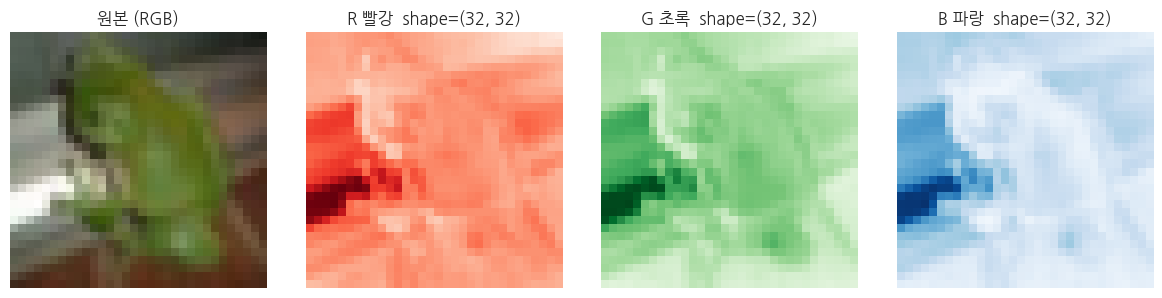

그레이스케일 shape : (32, 32)   ← 채널이 사라져 2차원이 되었다


In [5]:
fig, ax = plt.subplots(1, 4, figsize=(12, 3))
ax[0].imshow(img); ax[0].set_title('원본 (RGB)')
for i, (name, cmap) in enumerate([('R 빨강','Reds'), ('G 초록','Greens'), ('B 파랑','Blues')]):
    ax[i+1].imshow(img[:, :, i], cmap=cmap, vmin=0, vmax=255)
    ax[i+1].set_title(f'{name}  shape={img[:, :, i].shape}')
for a in ax: a.axis('off')
plt.tight_layout(); plt.show()

# 그레이스케일 = 세 채널의 가중 평균 (색 정보를 버린다)
gray = (0.299*img[:,:,0] + 0.587*img[:,:,1] + 0.114*img[:,:,2])
print('그레이스케일 shape :', gray.shape, '  ← 채널이 사라져 2차원이 되었다')

### 1-3. 픽셀 거리 실험 — **이 실습의 핵심**  *(슬라이드 10)*

같은 사진을 **2픽셀만 옮기거나 밝기만 바꿔도** 픽셀 거리가 얼마나 커지는지, 그리고 그것이 **전혀 다른 사진**과의 거리보다 큰지 직접 확인합니다.

#### ✍️ 직접 구현 — 픽셀 L2 거리
두 이미지의 **모든 숫자 차이를 제곱해 더한 뒤 제곱근**을 씌우면 픽셀 L2 거리입니다.
$$\text{거리} = \sqrt{\sum (a - b)^2}$$

A vs B (2픽셀 이동) : 1731.7
A vs C (밝기 +70)   : 3829.8
A vs D (다른 사진)   : 3490.0


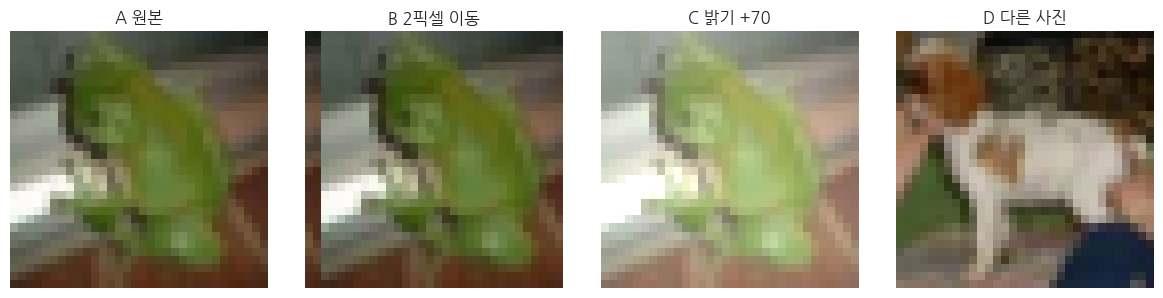

In [6]:
def l2_distance(a, b):
    """두 이미지의 픽셀 L2 거리 = 모든 숫자 차이를 제곱해 더한 뒤 제곱근."""
    a = a.astype(np.float32); b = b.astype(np.float32)
    # TODO: 두 이미지의 차이를 제곱해 모두 더한 뒤 제곱근을 씌워 반환하세요.
    return float(np.sqrt(np.sum((a - b) ** 2)))

# (아래는 그대로 실행 — 위에서 만든 함수를 써서 네 경우의 거리를 비교)
A = X_db[7].astype(np.float32)
B = np.roll(A, 2, axis=1)          # 2픽셀 오른쪽 이동
C = np.clip(A + 70, 0, 255)        # 밝기 +70
D = X_db[12].astype(np.float32)    # 전혀 다른 사진 (고정)
print('A vs B (2픽셀 이동) :', round(l2_distance(A, B), 1))
print('A vs C (밝기 +70)   :', round(l2_distance(A, C), 1))
print('A vs D (다른 사진)   :', round(l2_distance(A, D), 1))
fig, ax = plt.subplots(1,4,figsize=(12,3))
for a,t,im in zip(ax,['A 원본','B 2픽셀 이동','C 밝기 +70','D 다른 사진'],[A,B,C,D]):
    a.imshow(im.astype(np.uint8)); a.set_title(t); a.axis('off')
plt.tight_layout(); plt.show()

> ### ✅ 확인 질문 (제출)
> **“밝기만 바꾼 사진(C)”이 “전혀 다른 사진(D)”보다 멀게 나왔나요? 왜 그럴까요?**
> 한 문장으로 적어 보세요. 이 답이 §2 표현학습의 출발점입니다.
>
> **답:**

### 1-4. 커널을 직접 적용해 보기 — 필터 하나가 특성맵 한 장  *(슬라이드 12·13)*

3×3 커널(필터)을 이미지 위로 훑으며 **곱하고 더하면** 특성맵이 나옵니다.
**커널을 여러 개 쓰면 특성맵도 여러 장** 나온다는 것(슬라이드 13)을 눈으로 확인합니다.

#### ✍️ 직접 구현 — 합성곱의 한 칸
창(window) 하나에서 하는 일은 딱 하나: **그 창과 커널을 원소별로 곱해서 모두 더한다.** 이걸 모든 위치에서 반복하면 특성맵이 됩니다.

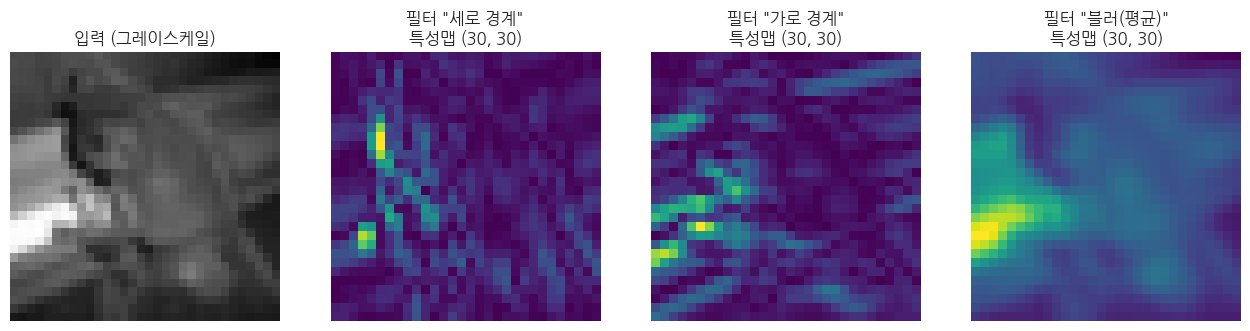

필터 3개 → 특성맵 3장 : 필터 N개면 특성맵(채널) N장 (슬라이드 13)


In [8]:
def convolve2d(image, kernel):
    """패딩 없는 2차원 합성곱. image (H,W), kernel (k,k) → (H-k+1, W-k+1)"""
    k = kernel.shape[0]; H, W = image.shape
    out = np.zeros((H-k+1, W-k+1), dtype=np.float32)
    for r in range(out.shape[0]):
        for c in range(out.shape[1]):
            # TODO: (r,c)에서 k×k 창을 잘라 커널과 원소별로 곱한 뒤 모두 더해 out[r,c]에 넣으세요.
            window = image[r:r+k, c:c+k]           # (r,c)에서 잘라낸 3×3 창
            out[r, c] = np.sum(window*kernel)
    return out

# (아래는 그대로 실행 — 필터 3개를 적용해 특성맵 3장을 그린다)
filters = {
    '세로 경계': np.array([[-1,0,1],[-1,0,1],[-1,0,1]], np.float32),
    '가로 경계': np.array([[-1,-1,-1],[0,0,0],[1,1,1]], np.float32),
    '블러(평균)': np.ones((3,3), np.float32) / 9,
}
fig, ax = plt.subplots(1, 4, figsize=(13, 3.3))
ax[0].imshow(gray, cmap='gray'); ax[0].set_title('입력 (그레이스케일)'); ax[0].axis('off')
for i, (name, korn) in enumerate(filters.items()):
    fmap = convolve2d(gray, korn)
    ax[i+1].imshow(np.abs(fmap), cmap='viridis')
    ax[i+1].set_title(f'필터 "{name}"\n특성맵 {fmap.shape}'); ax[i+1].axis('off')
plt.tight_layout(); plt.show()
print('필터 3개 → 특성맵 3장 : 필터 N개면 특성맵(채널) N장 (슬라이드 13)')

### 1-5. 전처리 함수 — 한 번 만들어 세 곳에서 쓴다  *(슬라이드 11·36)*  · (실행만)
**학습·인덱싱·질의** 세 경로가 **같은 전처리**를 써야 합니다(슬라이드 36). 그래서 함수 하나로 만들어 둡니다.

In [10]:
def prep_pretrained(images):
    """이미지(N,32,32,3, uint8) → MobileNetV2 입력용.
    1) 96×96 크기 조정  2) 그 모델이 학습 때 쓰던 규약으로 정규화(preprocess_input)"""
    x = tf.image.resize(tf.cast(images, tf.float32), (96, 96))
    return tf.keras.applications.mobilenet_v2.preprocess_input(x)   # 0~255 → -1~1

sample = prep_pretrained(X_db[:4])
print('전처리 후 shape :', sample.shape, '· 값 범위 : %.1f ~ %.1f (약 -1~1이면 성공)'
      % (float(tf.reduce_min(sample)), float(tf.reduce_max(sample))))

전처리 후 shape : (4, 96, 96, 3) · 값 범위 : -1.0 ~ 1.0 (약 -1~1이면 성공)


---
# 실습 2 — CNN을 직접 만들어 보기

> **강의 대응** §0 슬라이드 14~19
> **목표** 실습 1에서 **손으로** 적용한 커널을, 이번엔 **모델로 쌓아 학습**시킨다.
> 마지막에 **분류 헤드를 떼어** 임베딩을 꺼내 보며 실습 3으로 넘어간다.

**※ CPU로 1분 안팎 학습합니다.** 쌓기 → 학습 → 들여다보기 → 임베딩, 네 토막입니다.

### 2-0. 분류기 학습용 데이터 나누기  · (실행만)
검색용 DB·질의는 그대로 두고, **분류기 학습에 쓸 이름만 따로** 만듭니다(뒤 실습과 겹치지 않게).

In [11]:
y_all = np.asarray(y_test).ravel()
X_cls_train, y_cls_train = x_test[2000:7000], y_all[2000:7000]   # 학습 5,000장 (실습 4와 같은 구간)
X_cls_val,   y_cls_val   = x_test[:2000],     y_all[:2000]       # 평가 2,000장 (검색 DB와 같은 구간)

print('학습 :', X_cls_train.shape, '· 평가 :', X_cls_val.shape)
print('클래스별 학습 장수 :', np.bincount(y_cls_train, minlength=10))

학습 : (5000, 32, 32, 3) · 평가 : (2000, 32, 32, 3)
클래스별 학습 장수 : [508 491 506 499 524 522 482 509 469 490]


### 2-1. 모델 쌓기 — 그림이 그대로 코드가 된다  *(슬라이드 17)*

#### ✍️ 직접 구현 — CNN 분류기
슬라이드 17의 구조 그대로입니다. **conv → pool 을 세 번** 쌓고, **GAP** 로 공간을 접은 뒤, **Dense(10)** 으로 클래스 확률을 냅니다.
- `Conv2D(필터수, 3, padding='same', activation='relu')` — 필터 수는 32 → 64 → 128
- `MaxPooling2D()` — 가로·세로를 절반으로
- `GlobalAveragePooling2D()` — 특성맵 한 장을 값 하나로 (공간을 접는다)
- `Dense(10, activation='softmax')` — 분류 헤드

In [15]:
def build_cnn(n_classes=10):
    """슬라이드 17의 구조: conv-pool ×3 → GAP → Dense(10)"""
    inp = tf.keras.Input((32, 32, 3))
    x = tf.keras.layers.Rescaling(1./255)(inp)              # 0~255 → 0~1 (전처리를 모델 안에)

    # TODO: conv → pool 을 세 번 쌓으세요. 필터 수는 32 → 64 → 128,
    #       이름은 conv1/pool1, conv2/pool2, conv3/pool3 으로 붙입니다(2-7·2-8에서 씁니다).
    x = tf.keras.layers.Conv2D(32,3,padding='same',activation='relu', name='conv1')(x)
    x = tf.keras.layers.MaxPooling2D(name='pool1')(x)
    x = tf.keras.layers.Conv2D(64,3,padding='same',activation='relu', name='conv2')(x)
    x = tf.keras.layers.MaxPooling2D(name='pool2')(x)
    x = tf.keras.layers.Conv2D(128,3,padding='same',activation='relu', name='conv3')(x)
    x = tf.keras.layers.MaxPooling2D(name='pool3')(x)

    # TODO: GAP 로 공간을 접으세요 (이름은 'gap')
    x = tf.keras.layers.GlobalAveragePooling2D(name='gap')(x)
    # TODO: Dense 로 분류 헤드를 만드세요 (이름은 'head', softmax)
    out = tf.keras.layers.Dense(n_classes,activation='softmax',name='head')(x)
    return tf.keras.Model(inp, out, name='cnn_classifier')

model = build_cnn()
model.summary()

# 학습 전 1층 커널을 복사해 둔다 (2-7에서 학습 후와 비교할 것)
w_before = model.get_layer('conv1').get_weights()[0].copy()
print('\n1층 커널 모양 :', w_before.shape, '  ← (3, 3, 입력채널 3, 필터 32장)')

Model: "cnn_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_3 (Rescaling)         │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head (Dense)                    │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,538 (369.29 KB)

 Trainable params: 94,538 (369.29 KB)

 Non-trainable params: 0 (0.00 B)


1층 커널 모양 : (3, 3, 3, 32)   ← (3, 3, 입력채널 3, 필터 32장)


### 2-2. shape 흐름 확인 — 슬라이드 17의 그림을 숫자로  · (실행만)

In [16]:
print(f'{"층 이름":<12s} {"출력 모양":<20s} 설명')
print('-' * 58)
설명 = {'conv1': '필터 32장 → 채널 32',  'pool1': '가로·세로 절반',
        'conv2': '필터 64장 → 채널 64',  'pool2': '가로·세로 절반',
        'conv3': '필터 128장 → 채널 128', 'pool3': '가로·세로 절반',
        'gap'  : '공간을 접어 벡터 하나', 'head' : '클래스 10개의 확률'}
for lyr in model.layers:
    if lyr.name in 설명:
        print(f'{lyr.name:<12s} {str(lyr.output.shape):<20s} {설명[lyr.name]}')
print('\n※ 맨 앞 None 은 "한 번에 몇 장을 넣든 상관없다"는 뜻(배치 크기)입니다.')

층 이름         출력 모양                설명
----------------------------------------------------------
conv1        (None, 32, 32, 32)   필터 32장 → 채널 32
pool1        (None, 16, 16, 32)   가로·세로 절반
conv2        (None, 16, 16, 64)   필터 64장 → 채널 64
pool2        (None, 8, 8, 64)     가로·세로 절반
conv3        (None, 8, 8, 128)    필터 128장 → 채널 128
pool3        (None, 4, 4, 128)    가로·세로 절반
gap          (None, 128)          공간을 접어 벡터 하나
head         (None, 10)           클래스 10개의 확률

※ 맨 앞 None 은 "한 번에 몇 장을 넣든 상관없다"는 뜻(배치 크기)입니다.


### 2-3. 파라미터 수 — GAP가 아꼈다  *(슬라이드 17 오른쪽 상자)*  · (실행만)

In [18]:
gap_dim = model.get_layer('gap').output.shape[-1]      # 128
flat_dim = int(np.prod(model.get_layer('pool3').output.shape[1:]))   # 4 × 4 × 128

print(f'GAP 를 쓰면      : Dense({gap_dim} → 10) = {gap_dim*10 + 10:,} 개')
print(f'Flatten 을 쓰면  : Dense({flat_dim} → 10) = {flat_dim*10 + 10:,} 개')
print(f'→ 약 {(flat_dim*10+10) / (gap_dim*10+10):.0f}배 차이\n')

print(f'모델 전체 파라미터 : {model.count_params():,} 개')
print('합성곱층은 같은 커널을 모든 위치에서 재사용하므로(가중치 공유),')
print('같은 일을 완전연결층으로 하는 것보다 파라미터가 훨씬 적습니다.')

GAP 를 쓰면      : Dense(128 → 10) = 1,290 개
Flatten 을 쓰면  : Dense(2048 → 10) = 20,490 개
→ 약 16배 차이

모델 전체 파라미터 : 94,538 개
합성곱층은 같은 커널을 모든 위치에서 재사용하므로(가중치 공유),
같은 일을 완전연결층으로 하는 것보다 파라미터가 훨씬 적습니다.


### 2-4. compile + fit — 여기서 비로소 커널이 바뀐다  *(슬라이드 18)*

#### ✍️ 직접 구현 — 학습 설정
- `optimizer='adam'`
- `loss='sparse_categorical_crossentropy'` — 정답이 **정수 라벨**(0~9)일 때 쓰는 크로스 엔트로피
- `metrics=['accuracy']`

In [19]:
# TODO: optimizer, loss, metrics 를 채우세요.
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

t0 = time.time()
history_cls = model.fit(X_cls_train, y_cls_train,
                        validation_data=(X_cls_val, y_cls_val),
                        epochs=10, batch_size=64, verbose=2)
print(f'\n학습 완료 · {time.time()-t0:.0f}초')

Epoch 1/10
79/79 - 13s - 160ms/step - accuracy: 0.1850 - loss: 2.1679 - val_accuracy: 0.2545 - val_loss: 2.0378
Epoch 2/10
79/79 - 22s - 276ms/step - accuracy: 0.2676 - loss: 1.9628 - val_accuracy: 0.2705 - val_loss: 1.9404
Epoch 3/10
79/79 - 11s - 143ms/step - accuracy: 0.3162 - loss: 1.8653 - val_accuracy: 0.3080 - val_loss: 1.8939
Epoch 4/10
79/79 - 11s - 140ms/step - accuracy: 0.3506 - loss: 1.7689 - val_accuracy: 0.3130 - val_loss: 1.8824
Epoch 5/10
79/79 - 22s - 280ms/step - accuracy: 0.3824 - loss: 1.7099 - val_accuracy: 0.3835 - val_loss: 1.7308
Epoch 6/10
79/79 - 10s - 126ms/step - accuracy: 0.4068 - loss: 1.6465 - val_accuracy: 0.4100 - val_loss: 1.6884
Epoch 7/10
79/79 - 11s - 137ms/step - accuracy: 0.4186 - loss: 1.6006 - val_accuracy: 0.4250 - val_loss: 1.6510
Epoch 8/10
79/79 - 14s - 174ms/step - accuracy: 0.4378 - loss: 1.5580 - val_accuracy: 0.4325 - val_loss: 1.6242
Epoch 9/10
79/79 - 22s - 282ms/step - accuracy: 0.4554 - loss: 1.5203 - val_accuracy: 0.4355 - val_loss:

### 2-5. 학습 곡선 — 손실은 내려가고 정확도는 올라가는가  · (실행만)

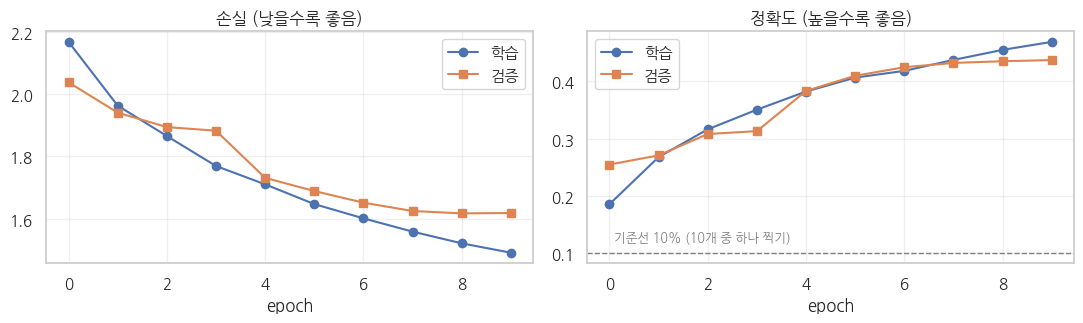

마지막 검증 정확도 : 43.8%  (기준선 10%)


In [20]:
h = history_cls.history
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].plot(h['loss'], 'o-', label='학습');      ax[0].plot(h['val_loss'], 's-', label='검증')
ax[0].set_title('손실 (낮을수록 좋음)');         ax[0].set_xlabel('epoch'); ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].plot(h['accuracy'], 'o-', label='학습');  ax[1].plot(h['val_accuracy'], 's-', label='검증')
ax[1].axhline(0.1, ls='--', c='gray', lw=1)
ax[1].text(0.1, 0.12, '기준선 10% (10개 중 하나 찍기)', fontsize=9, color='gray')
ax[1].set_title('정확도 (높을수록 좋음)');       ax[1].set_xlabel('epoch'); ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

print(f"마지막 검증 정확도 : {h['val_accuracy'][-1]*100:.1f}%  (기준선 10%)")

### 2-6. 무엇을 맞히고 무엇을 틀렸나 — 혼동 행렬  · (실행만)

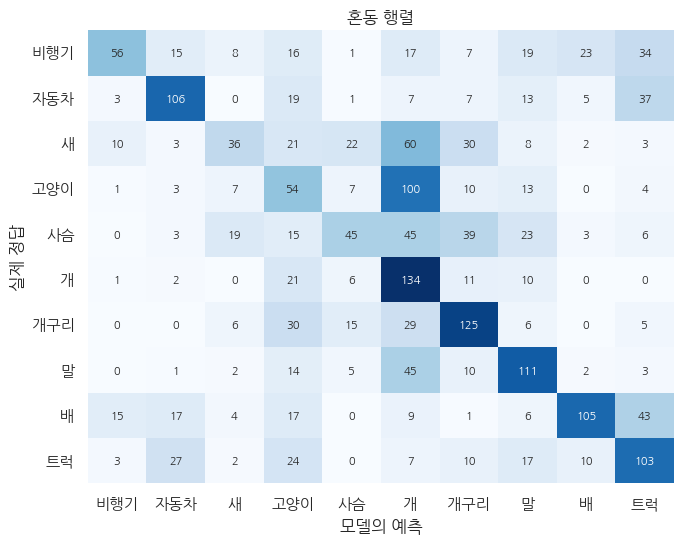

고양이 을(를) 개 로 잘못 본 경우 : 100건
새 을(를) 개 로 잘못 본 경우 : 60건
말 을(를) 개 로 잘못 본 경우 : 45건


In [21]:
from sklearn.metrics import confusion_matrix

pred = model.predict(X_cls_val, batch_size=256, verbose=0).argmax(axis=1)
cm = confusion_matrix(y_cls_val, pred)

plt.figure(figsize=(7, 5.6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=CLASS, yticklabels=CLASS, annot_kws={'size': 8})
plt.xlabel('모델의 예측'); plt.ylabel('실제 정답'); plt.title('혼동 행렬')
plt.tight_layout(); plt.show()

# 가장 자주 헷갈린 짝 세 개 (대각선=정답은 빼고, 실제로 틀린 것만)
off = cm.copy(); np.fill_diagonal(off, 0)
pairs = [(off[r, c], r, c) for r in range(10) for c in range(10) if r != c and off[r, c] > 0]
for n_err, r, c in sorted(pairs, reverse=True)[:3]:
    print(f'{CLASS[r]} 을(를) {CLASS[c]} 로 잘못 본 경우 : {n_err}건')
if not pairs:
    print('틀린 예측이 없습니다.')

> ### ✅ 확인 질문 (제출)
> **가장 자주 헷갈린 짝은 무엇이었나요? 그 둘은 "시각적으로" 닮았나요?**
> 한 문장으로 적어 보세요. (이 질문이 §2의 **"같은 클래스라고 항상 시각적으로 닮은 것은 아니다"** 와 이어집니다.)
>
> **답:**

### 2-7. 학습 전후의 1층 커널 — 슬라이드 18의 그림을 실제로  · (실행만)
실습 1-4에서 세로 경계 커널 `[-1, 0, 1]` 을 **사람이 손으로** 넣었습니다.
학습 뒤의 커널이 그와 비슷한 모양을 **스스로** 찾아냈는지 확인하세요.

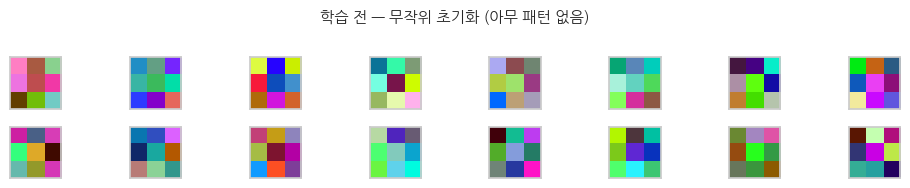

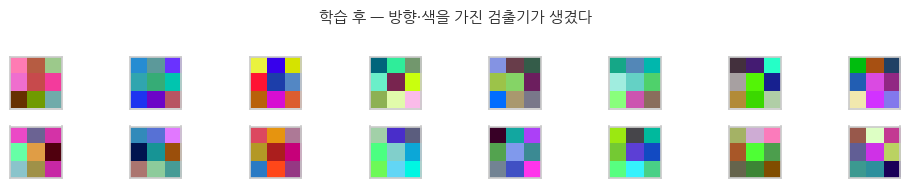

바뀐 것은 이 숫자들뿐입니다. 구조도 코드도 그대로입니다.
1층 커널 가중치 개수 : 864 개  (3×3×3×32)


In [22]:
w_after = model.get_layer('conv1').get_weights()[0]      # (3, 3, 3, 32)

def show_kernels(w, title, n=16):
    """3×3×3 커널 n개를 RGB 패치로 그린다 (값을 0~1로 정규화)."""
    fig, ax = plt.subplots(2, n//2, figsize=(n*0.62, 1.9))
    for i, a in enumerate(ax.ravel()):
        k = w[:, :, :, i]
        k = (k - k.min()) / (k.max() - k.min() + 1e-9)
        a.imshow(k); a.set_xticks([]); a.set_yticks([])
    fig.suptitle(title, fontsize=11); plt.tight_layout(); plt.show()

show_kernels(w_before, '학습 전 — 무작위 초기화 (아무 패턴 없음)')
show_kernels(w_after,  '학습 후 — 방향·색을 가진 검출기가 생겼다')

print('바뀐 것은 이 숫자들뿐입니다. 구조도 코드도 그대로입니다.')
print('1층 커널 가중치 개수 :', w_after.size, '개  (3×3×3×32)')

### 2-8. 층별 특성맵 — 깊어질수록 무엇이 보이나  *(슬라이드 13·15)*

#### ✍️ 직접 구현 — 중간층 출력 꺼내기
학습이 끝난 모델에서 **중간 층의 출력**을 보려면, 입력은 그대로 두고 **출력만 그 층으로 바꾼 모델**을 만들면 됩니다.
`tf.keras.Model(model.input, model.get_layer(이름).output)`

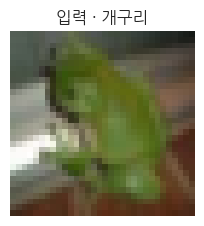

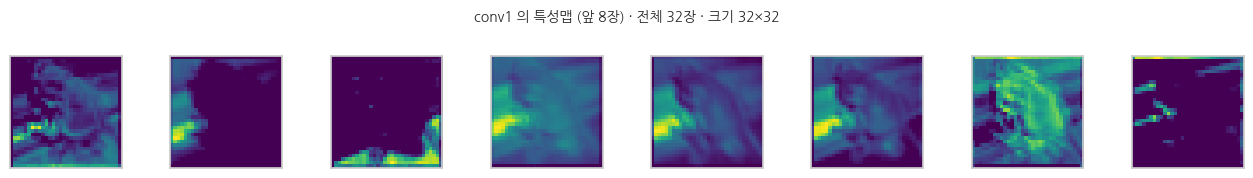

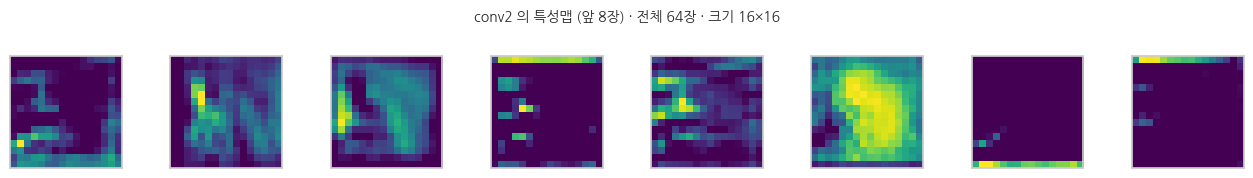

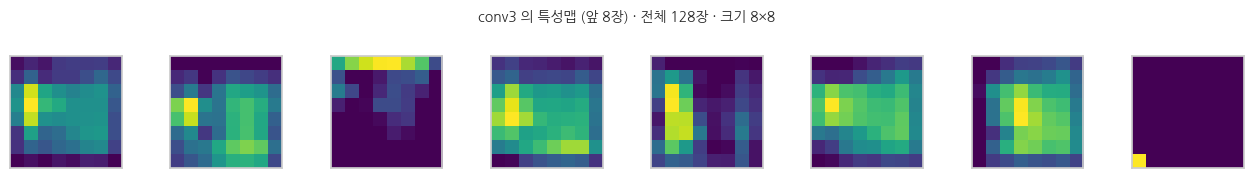

In [23]:
def feature_maps(layer_name, image):
    """지정한 층의 특성맵을 꺼낸다."""
    # TODO: 입력은 model.input 그대로, 출력만 해당 층으로 바꾼 모델을 만드세요.
    probe = tf.keras.Model(model.input,model.get_layer(layer_name).output)
    return probe.predict(image[None, ...], verbose=0)[0]      # (H, W, 채널수)

img_fm = X_cls_val[7]
plt.figure(figsize=(2.4, 2.4)); plt.imshow(img_fm)
plt.title(f'입력 · {CLASS[y_cls_val[7]]}'); plt.axis('off'); plt.show()

for name in ['conv1', 'conv2', 'conv3']:
    fmaps = feature_maps(name, img_fm)
    fig, ax = plt.subplots(1, 8, figsize=(13, 1.8))
    for i, a in enumerate(ax):
        a.imshow(fmaps[:, :, i], cmap='viridis'); a.set_xticks([]); a.set_yticks([])
    fig.suptitle(f'{name} 의 특성맵 (앞 8장) · 전체 {fmaps.shape[-1]}장 · 크기 {fmaps.shape[0]}×{fmaps.shape[1]}',
                 fontsize=10)
    plt.tight_layout(); plt.show()

### 2-9. 헤드를 떼어 내면 남는 것 — 임베딩  *(슬라이드 19)*

#### ✍️ 직접 구현 — 임베딩 추출기
방법은 2-8과 똑같습니다. 출력을 **`'head'` 가 아니라 `'gap'`** 으로 바꾸면 끝입니다.
다음 실습 3에서 쓸 `include_top=False, pooling='avg'` 가 바로 이 일을 한 줄로 한 것입니다.

In [24]:
# TODO: 출력을 'gap' 층으로 바꾼 모델을 만드세요.
embedder = tf.keras.Model(model.input,model.get_layer('gap').output)
print('임베딩 추출기 출력 :', embedder.output.shape, '  ← 분류 확률(10)이 아니라 벡터(128)')

emb_cnn = embedder.predict(X_cls_val, batch_size=256, verbose=0)
emb_cnn = emb_cnn / np.maximum(np.linalg.norm(emb_cnn, axis=1, keepdims=True), 1e-12)   # 길이 1로
print('임베딩 :', emb_cnn.shape)

임베딩 추출기 출력 : (None, 128)   ← 분류 확률(10)이 아니라 벡터(128)


임베딩 : (2000, 128)


### 2-10. 임베딩 공간을 2차원으로 펼쳐 보기  · (실행만)
128차원은 그릴 수 없으므로 **PCA로 2차원**만 남겨 봅니다.
같은 색(같은 클래스)끼리 모여 있다면, 그 공간에서 **"가까움 = 닮음"** 이 성립한다는 뜻입니다.

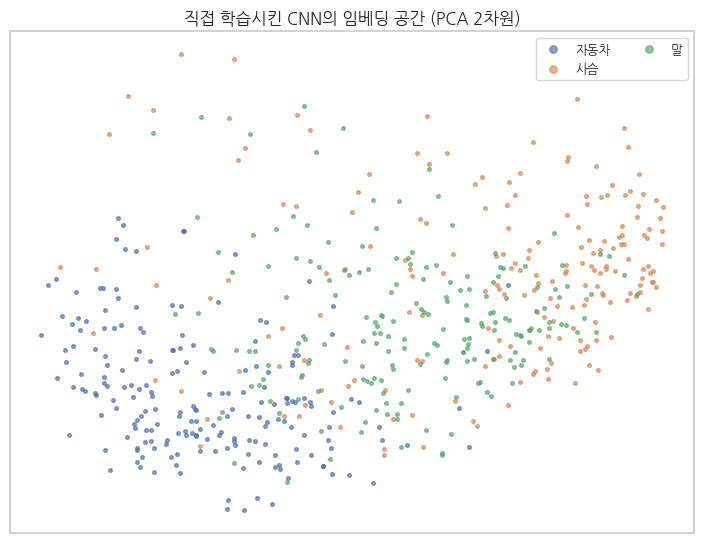

In [26]:
from sklearn.decomposition import PCA

xy = PCA(n_components=2, random_state=42).fit_transform(emb_cnn)

plt.figure(figsize=(7.2, 5.6))
for c in [1,4,7]:
    m = y_cls_val == c
    plt.scatter(xy[m, 0], xy[m, 1], s=7, alpha=.65, label=CLASS[c])
plt.legend(markerscale=2, fontsize=9, ncol=2, loc='best')
plt.title('직접 학습시킨 CNN의 임베딩 공간 (PCA 2차원)')
plt.xticks([]); plt.yticks([]); plt.tight_layout(); plt.show()

> ### ✅ 확인 질문 (제출)
> 1. 분류기로 학습시켰을 뿐인데 같은 클래스끼리 모이는 이유는 무엇일까요?
> 2. 그런데 **같은 클래스 안에서는** 어떻게 배치돼 있을까요? 흰 자동차와 검은 자동차가 구분될까요?
>    (2번이 바로 슬라이드 19가 말한 **"분류로 학습한 특징의 한계"** 이고, 실습 4에서 대조학습으로 고치려는 문제입니다.)
>
> **답:**
>
> ---
> 다음 실습 3에서는 우리가 학습시킨 이 작은 CNN 대신, **ImageNet으로 학습된 큰 모델**의 헤드를 떼어
> 같은 일을 해 봅니다. 방법은 똑같고 모델만 커집니다.

---
# 실습 3 — 사전학습 임베딩으로 유사 이미지 찾기

> **강의 대응** §0 슬라이드 19, §3 슬라이드 36
> **목표** 학습을 전혀 하지 않고도, **분류용으로 학습된 CNN의 헤드를 떼어(GAP)** 검색을 해 본다.
> 실습 2에서 직접 한 일을, 이번엔 **훨씬 큰 사전학습 모델**로 한 줄에 해냅니다.

### 3-1. 모델 불러오기 — `include_top=False, pooling='avg'`  *(슬라이드 16·19)*  · (실행만)
이 두 옵션이 강의의 **"분류 헤드 제거 + GAP"** 입니다. GAP가 특성맵마다 값 하나를 뽑아 고정 길이 벡터를 만듭니다.
실습 2-9에서 `Model(model.input, ...get_layer('gap').output)` 으로 했던 일과 **같은 일**입니다.

In [32]:
backbone = tf.keras.applications.MobileNetV2(
    input_shape=(96, 96, 3),
    include_top=False,   # ← 분류 헤드를 떼어 낸다
    pooling='avg',       # ← 전역 평균 풀링(GAP): 특성맵마다 값 하나 → 고정 길이 벡터
    weights='imagenet',  # ← ImageNet에서 배운 가중치 (전이학습)
)
backbone.trainable = False
print('임베딩(벡터) 길이 :', backbone.output_shape[-1], '  ← GAP가 만든 고정 길이')

임베딩(벡터) 길이 : 1280   ← GAP가 만든 고정 길이


### 3-2. 임베딩 추출 — 이미지 한 장 → 벡터 한 개  · (실행만)
L2 정규화를 하면 **내적이 곧 코사인 유사도**가 됩니다(슬라이드 43·45). 이 성질을 다음 검색에서 씁니다.

In [33]:
def l2_normalize(v):
    """벡터를 길이 1로 만든다 → 내적이 곧 코사인 유사도가 된다."""
    return v / np.maximum(np.linalg.norm(v, axis=1, keepdims=True), 1e-12)

t0 = time.time()
emb_pre = l2_normalize(backbone.predict(prep_pretrained(X_db), batch_size=64, verbose=0))
print(f'사전학습 임베딩 {emb_pre.shape} 계산 완료 · {time.time()-t0:.1f}초')
print('벡터 하나의 길이 :', round(float(np.linalg.norm(emb_pre[0])), 3), '← 1이면 정규화 성공')

사전학습 임베딩 (2000, 1280) 계산 완료 · 23.2초
벡터 하나의 길이 : 1.0 ← 1이면 정규화 성공


### 3-3. 검색해 보기 — 코사인 유사도로 가장 가까운 이미지 찾기

#### ✍️ 직접 구현 — 검색 함수
임베딩이 이미 길이 1로 정규화돼 있으므로, **질의 벡터와 전체의 내적**이 곧 코사인 유사도입니다. 그 값이 **높은 순으로 정렬**하면 가장 닮은 이미지가 앞에 옵니다.

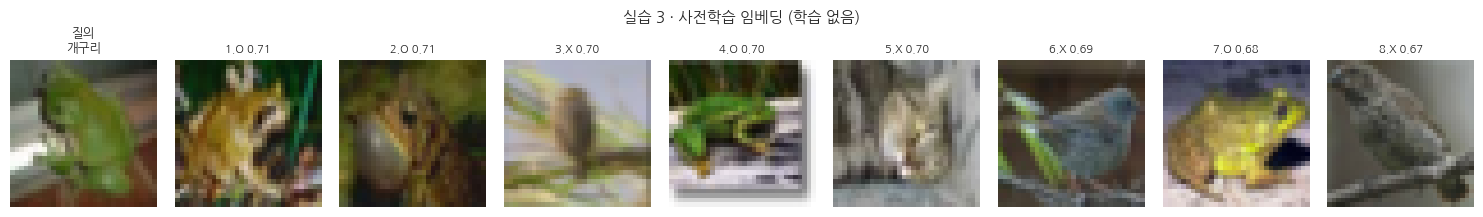

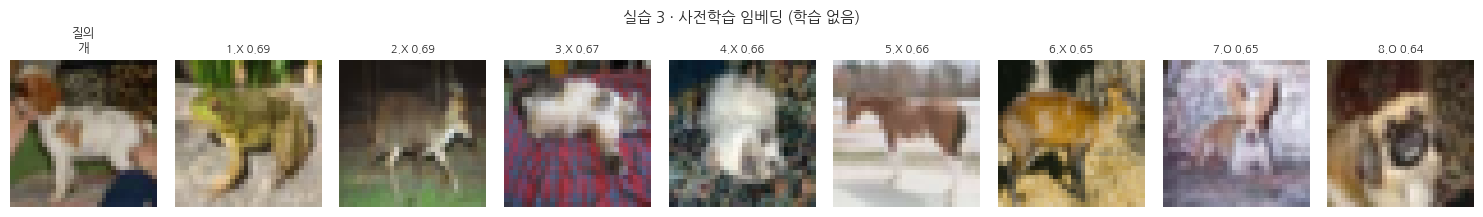

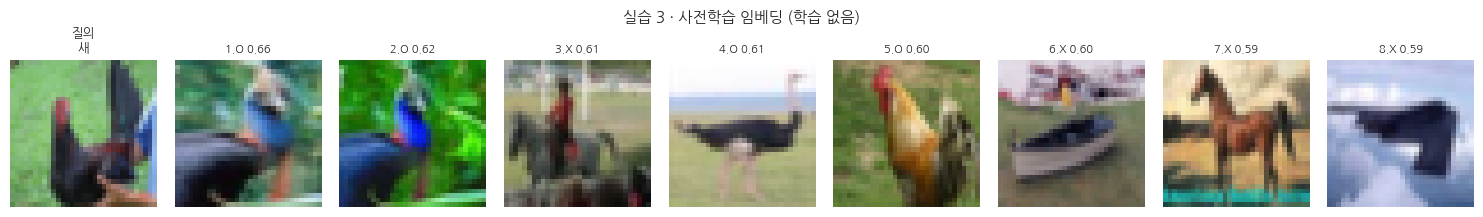

In [34]:
def search(emb, q_index, k=8):
    """질의와 전체의 코사인 유사도(정규화 벡터의 내적)를 구해 가까운 상위 k개."""
    # TODO: 임베딩 행렬과 질의 벡터의 내적으로 유사도를 구하세요.
    sims = emb@emb[q_index]
    # TODO: 유사도가 높은 순으로 인덱스를 정렬하세요 (내림차순).
    order = np.argsort(-sims)
    order = order[order != q_index]     # 자기 자신은 제외
    return order[:k], sims

# (아래는 그대로 실행 — 검색 결과를 그림으로 확인)
def show(emb, q_index, title):
    top, sims = search(emb, q_index)
    fig, ax = plt.subplots(1, 9, figsize=(15, 2.2))
    ax[0].imshow(X_db[q_index]); ax[0].set_title(f'질의\n{CLASS[y_db[q_index]]}', fontsize=9); ax[0].axis('off')
    for i, j in enumerate(top):
        ax[i+1].imshow(X_db[j])
        mark = 'O' if y_db[j] == y_db[q_index] else 'X'   # 같은 클래스면 O
        ax[i+1].set_title(f'{i+1}.{mark} {sims[j]:.2f}', fontsize=8); ax[i+1].axis('off')
    fig.suptitle(title, fontsize=11); plt.tight_layout(); plt.show()

for q in QUERIES[:3]:
    show(emb_pre, q, '실습 3 · 사전학습 임베딩 (학습 없음)')

> ### ✅ 확인 질문 (제출)
> 이 모델은 **"분류"** 를 배우도록 학습됐는데도 검색이 어느 정도 되는 이유는 무엇일까요?
> 그리고 **잘 안 되는 경우**(X가 많은 결과)는 어떤 이미지였나요? (슬라이드 19의 "한계", 그리고 실습 2-10의 확인 질문과 연결)
>
> **답:**

---
# 실습 4 — 대조학습으로 임베딩을 다시 배우기

> **강의 대응** §4 슬라이드 38~45
> **목표** 라벨 없이 **증강으로 양성 쌍**을 만들고, **NT-Xent 손실**로 임베딩을 직접 학습시킨다.

**※ 실습 2에 이어 두 번째로 모델을 학습시킵니다. CPU 기준 5~8분.** 학습 셀을 돌려 두고 강의를 들으세요.
이 실습은 개념이 어려우므로 **증강·인코더·손실 코드는 제공**하고, 여러분은 **흐름을 읽고 실행**하며 결과를 해석하는 데 집중합니다.

### 4-1. 증강 쌍 만들기 — 한 장을 두 번 다르게 보기  *(슬라이드 42)*  · (실행만)

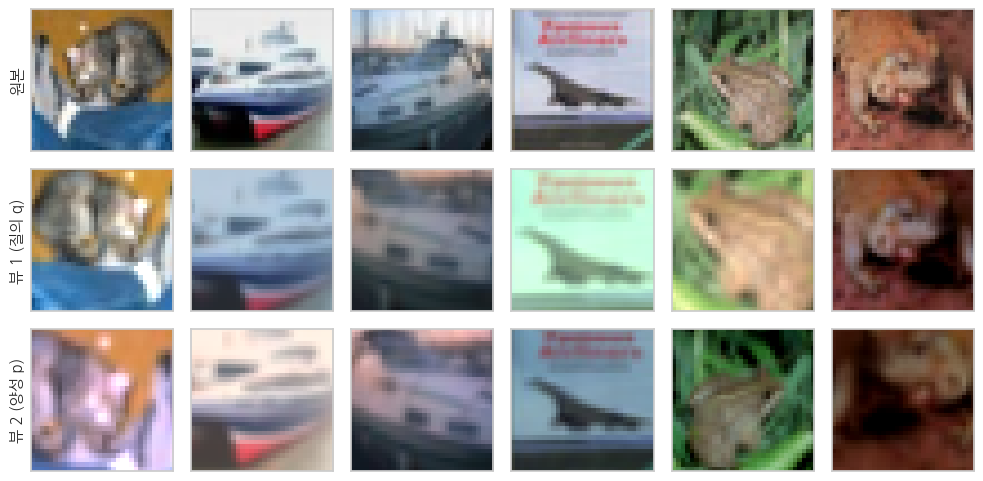

In [35]:
def random_resized_crop(x):
    """일부만 잘라내 다시 32x32로 늘린다 = '같은 물체를 다른 거리에서 본' 뷰."""
    s = tf.random.uniform([], 20, 32, dtype=tf.int32)        # 20~31 픽셀 정사각형
    c = tf.image.random_crop(x, (tf.shape(x)[0], s, s, 3))   # 위치는 무작위
    return tf.image.resize(c, (32, 32))

def augment(x):
    """0~1 입력·출력. 모든 변형을 '이미지마다 다른 난수'로 적용한다."""
    B = tf.shape(x)[0]
    r = lambda lo, hi: tf.random.uniform((B, 1, 1, 1), lo, hi)   # 장마다 다른 값

    # ① 잘라 확대 — 이미지마다 다른 위치·크기
    sz = tf.random.uniform((B,), 0.6, 1.0)                        # 원본의 60~100%
    y0 = tf.random.uniform((B,), 0.0, 1.0) * (1.0 - sz)
    x0 = tf.random.uniform((B,), 0.0, 1.0) * (1.0 - sz)
    boxes = tf.stack([y0, x0, y0 + sz, x0 + sz], axis=1)
    x = tf.image.crop_and_resize(x, boxes, tf.range(B), (32, 32))

    # ② 좌우 반전 — 장마다 독립
    x = tf.image.random_flip_left_right(x)

    # ③ 밝기 · 대비 · 색조(채널 게인) — 모두 장마다 다른 값
    x = x + r(-0.2, 0.2)
    m = tf.reduce_mean(x, axis=[1, 2], keepdims=True)
    x = (x - m) * r(0.7, 1.3) + m
    x = x * tf.random.uniform((B, 1, 1, 3), 0.85, 1.15)
    return tf.clip_by_value(x, 0.0, 1.0)

demo = X_db[:6].astype(np.float32) / 255.0          # 0~1로
v1, v2 = augment(demo), augment(demo)
fig, ax = plt.subplots(3, 6, figsize=(10, 5))
for i in range(6):
    ax[0,i].imshow(demo[i]); ax[1,i].imshow(v1[i]); ax[2,i].imshow(v2[i])
for r, t in enumerate(['원본', '뷰 1 (질의 q)', '뷰 2 (양성 p)']):
    ax[r,0].set_ylabel(t, fontsize=11)
for a in ax.ravel(): a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()

### 4-2. 인코더 — 작은 CNN이 임베딩을 출력한다  *(슬라이드 13·17)*  · (실행만)
실습 2에서 쌓은 구조와 **거의 같습니다**. 다른 점은 마지막에 `Dense(FC)` 로 **임베딩 차원을 따로 정하고**,
분류 헤드 대신 **길이 1로 정규화**한다는 것뿐입니다.

In [36]:
EMB_DIM = 64   # 임베딩 차원 — 우리가 정하는 하이퍼파라미터 (슬라이드 39, FC가 정한다)

def build_encoder():
    inp = tf.keras.Input((32, 32, 3))
    x = tf.keras.layers.Rescaling(1./255)(inp)              # 0~255 → 0~1 (전처리를 모델 안에)
    for f in (32, 64, 128):                                 # 필터 32→64→128개 (채널이 깊어진다)
        x = tf.keras.layers.Conv2D(f, 3, padding='same', activation='relu')(x)
        x = tf.keras.layers.MaxPooling2D()(x)               # 크기 절반 (32→16→8→4)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)         # ← GAP: 특성맵마다 값 하나 → 128차원
    x = tf.keras.layers.Dense(EMB_DIM)(x)                   # ← FC: 임베딩 64차원 (차원을 여기서 결정)
    x = tf.keras.layers.UnitNormalization()(x)             # ← 길이 1로 정규화
    return tf.keras.Model(inp, x, name='encoder')

encoder = build_encoder()
encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_4 (Rescaling)         │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ unit_normalization              │ (None, 64)             │             0 │
│ (UnitNormalization)             │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,504 (396.50 KB)

 Trainable params: 101,504 (396.50 KB)

 Non-trainable params: 0 (0.00 B)

### 4-3. NT-Xent 손실 — "유사도 → softmax → cross-entropy"  *(슬라이드 43·44)*  · (실행만)
배치 크기 N이면 뷰가 2N개. 각 뷰의 **양성은 딱 하나**(같은 원본의 짝), **나머지는 모두 음성**입니다. 슬라이드 43·44의 세 단계를 그대로 코드로 옮긴 것이니 **주석을 읽으며 실행**하세요.

In [37]:
def nt_xent(z1, z2, temperature=0.5):
    N = tf.shape(z1)[0]
    z = tf.concat([z1, z2], axis=0)                         # (2N, D): 두 뷰를 이어 붙임

    # ① 유사도: 정규화 벡터의 내적 = 코사인 유사도, 온도로 나눔
    sim = tf.matmul(z, z, transpose_b=True) / temperature   # (2N, 2N)
    sim = sim - tf.eye(2*N) * 1e9                            # 자기 자신끼리는 제외(아주 작게)

    # 정답 위치: i번째 뷰의 양성은 (i+N)번째 뷰
    labels = tf.concat([tf.range(N, 2*N), tf.range(0, N)], axis=0)

    # ②③ softmax + cross-entropy 를 한 번에 (= "양성의 위치를 맞히는 분류")
    return tf.reduce_mean(
        tf.nn.sparse_softmax_cross_entropy_with_logits(labels=labels, logits=sim))

### 4-4. 학습 실행 — 손실이 내려가는지 지켜보세요  · (실행만)

epoch 1/50  손실 = 4.8532  (82초)
epoch 2/50  손실 = 4.7429  (102초)
epoch 3/50  손실 = 4.7161  (143초)
epoch 4/50  손실 = 4.7149  (184초)
epoch 5/50  손실 = 4.7145  (205초)
epoch 6/50  손실 = 4.7065  (225초)
epoch 7/50  손실 = 4.7082  (246초)
epoch 8/50  손실 = 4.7023  (267초)
epoch 9/50  손실 = 4.7083  (287초)
epoch 10/50  손실 = 4.7109  (307초)
epoch 11/50  손실 = 4.7034  (327초)
epoch 12/50  손실 = 4.7007  (347초)
epoch 13/50  손실 = 4.7009  (367초)
epoch 14/50  손실 = 4.7143  (387초)
epoch 15/50  손실 = 4.6988  (407초)
epoch 16/50  손실 = 4.7043  (426초)
epoch 17/50  손실 = 4.6960  (447초)
epoch 18/50  손실 = 4.6964  (466초)
epoch 19/50  손실 = 4.6920  (487초)
epoch 20/50  손실 = 4.6919  (506초)
epoch 21/50  손실 = 4.6907  (527초)
epoch 22/50  손실 = 4.6876  (547초)
epoch 23/50  손실 = 4.6973  (588초)
epoch 24/50  손실 = 4.6957  (609초)
epoch 25/50  손실 = 4.6882  (628초)
epoch 26/50  손실 = 4.6838  (649초)
epoch 27/50  손실 = 4.6833  (668초)
epoch 28/50  손실 = 4.6880  (689초)
epoch 29/50  손실 = 4.6771  (708초)
epoch 30/50  손실 = 4.6895  (728초)
epoch 31/50  손실 = 4.

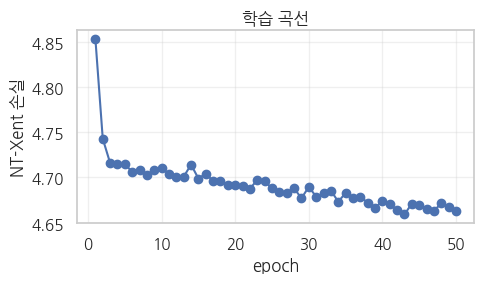

In [41]:
X_train = (x_test[2000:7000].astype(np.float32)) / 255.0   # 학습용 5000장 (DB와 겹치지 않게, 고정)
ds = tf.data.Dataset.from_tensor_slices(X_train).shuffle(2048, seed=42).batch(256, drop_remainder=True)   # 배치가 클수록 음성이 많아져 대조학습에 유리
opt = tf.keras.optimizers.Adam(1e-3)

@tf.function
def train_step(batch):
    with tf.GradientTape() as tape:
        # augment는 0~1에서 동작하고 encoder 안에 Rescaling(1./255)이 있으므로
        # 255를 되돌려 넣는다 (추론 때의 0~255 원본 입력과 같은 규칙).
        z1 = encoder(augment(batch) * 255.0, training=True)   # 뷰 1
        z2 = encoder(augment(batch) * 255.0, training=True)   # 뷰 2 (양성)
        loss = nt_xent(z1, z2)
    grads = tape.gradient(loss, encoder.trainable_variables)
    opt.apply_gradients(zip(grads, encoder.trainable_variables))
    return loss

EPOCHS = 50
history = []
t0 = time.time()
for e in range(EPOCHS):
    losses = [float(train_step(b)) for b in ds]
    history.append(np.mean(losses))
    print(f'epoch {e+1}/{EPOCHS}  손실 = {history[-1]:.4f}  ({time.time()-t0:.0f}초)')

plt.figure(figsize=(5,3)); plt.plot(range(1,EPOCHS+1), history, 'o-')
plt.xlabel('epoch'); plt.ylabel('NT-Xent 손실'); plt.title('학습 곡선'); plt.grid(alpha=.3)
plt.tight_layout(); plt.show()

### 4-5. 다시 검색해 보기 — 실습 3과 무엇이 달라졌나  · (실행만)

대조학습 임베딩 : (2000, 64)


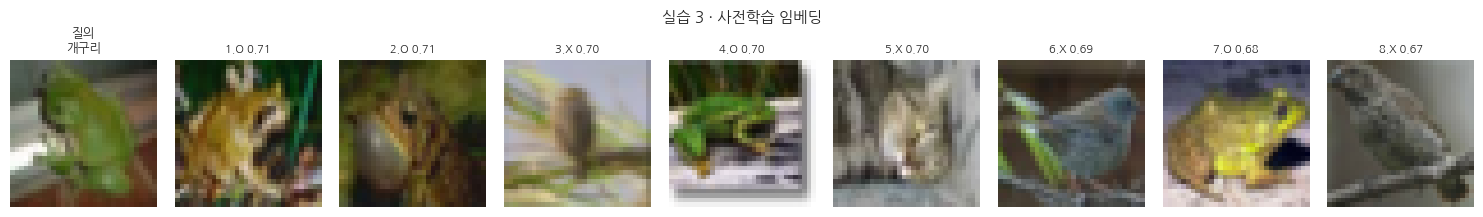

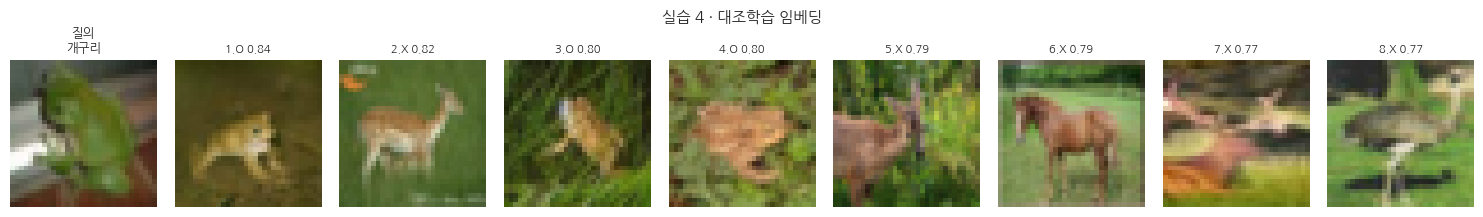

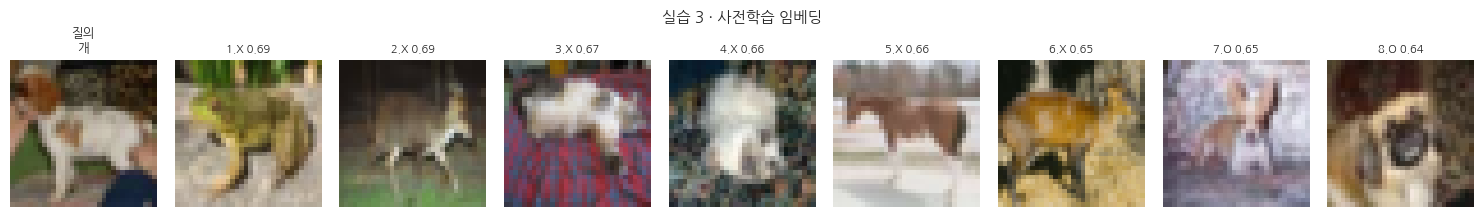

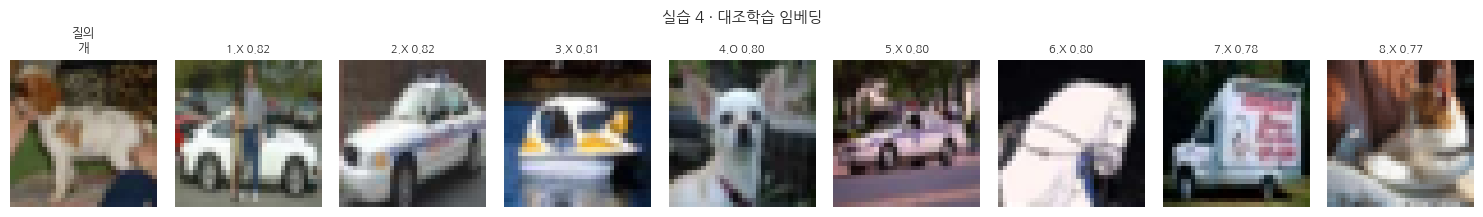

In [39]:
# 학습 때와 같은 규칙(0~255 원본 입력, 내부에서 Rescaling)으로 임베딩을 만든다
emb_con = l2_normalize(encoder.predict(X_db, batch_size=128, verbose=0))
print('대조학습 임베딩 :', emb_con.shape)

for q in QUERIES[:2]:
    show(emb_pre, q, '실습 3 · 사전학습 임베딩')
    show(emb_con, q, '실습 4 · 대조학습 임베딩')

> **관찰(제출)** 두 결과를 나란히 보고 무엇이 달라졌는지 한 문장으로 적어 보세요.
> (자주 나오는 관찰: 배경색이 아니라 **물체 모양**으로 묶이기 시작한다.) 인상만으로는 부족하니 실습 5에서 **숫자로** 확인합니다.

---
# 실습 5 — nDCG로 채점하기

> **강의 대응** §5 슬라이드 48~53
> **목표** 검색 순위의 품질을 nDCG로 재고, **세 가지 방식**(픽셀·사전학습·대조학습)을 숫자로 비교한다.

### 5-1. 정답 관련성 점수 만들기  *(슬라이드 52)*
| 관계 | 점수 |
|---|---|
| 같은 클래스 (예: 고양이 ↔ 고양이) | **5** |
| 같은 상위 그룹 (동물끼리 · 탈것끼리) | **2** |
| 그 외 | **0** |

#### ✍️ 직접 구현 — 관련성 점수
위 표의 규칙을 코드로 옮깁니다. 탈것 그룹은 `{0,1,8,9}`(비행기·자동차·배·트럭), 나머지는 동물입니다.

In [42]:
VEHICLES = {0, 1, 8, 9}    # 비행기·자동차·배·트럭
def relevance(q_label, cand_labels):
    """질의 라벨과 후보 라벨들 → 관련성 점수 배열 (0, 2, 5)"""
    q_is_vehicle = q_label in VEHICLES
    rel = np.zeros(len(cand_labels), dtype=np.float32)   # 기본값 0
    for i, c in enumerate(cand_labels):
        if c == q_label:                       # 같은 클래스
            rel[i] = 5
        elif (c in VEHICLES) == q_is_vehicle:  # 같은 상위 그룹(둘 다 탈것 or 둘 다 동물)
            rel[i] = 2
    return rel

print('질의가 고양이(3)일 때:')
for c in [3, 5, 1, 8]:
    print(f'  후보 {CLASS[c]:4s} → 관련성 {relevance(3, [c])[0]:.0f}')

질의가 고양이(3)일 때:
  후보 고양이  → 관련성 5
  후보 개    → 관련성 2
  후보 자동차  → 관련성 0
  후보 배    → 관련성 0


### 5-2. nDCG 구현 — 알려진 정답(0.687)으로 반드시 검증  *(슬라이드 52)*

#### ✍️ 직접 구현 — DCG와 nDCG
- **DCG** = 위에서부터 관련성을 더하되 아래로 갈수록 로그로 할인: $\text{DCG} = \sum_i \dfrac{rel_i}{\log_2(i+1)}$  (i는 1,2,3,…)
- **nDCG** = DCG ÷ IDCG (IDCG = 관련성을 내림차순으로 정렬했을 때의 DCG)
- 구현이 맞는지 **알려진 정답으로 검증**하는 습관을 들이세요. `[0,5,1,4,2]` → nDCG ≈ **0.687**.

In [ ]:
def dcg(rels):
    rels = np.asarray(rels, np.float32)
    # TODO: 분모 log2(i+1) 을 만들고(i는 1부터), rel을 나눠 모두 더해 반환하세요.
    denom = ...
    return ...

def ndcg(rels):
    # TODO: 관련성을 내림차순으로 정렬한 이상적 순위의 DCG(IDCG)로 나누세요. IDCG가 0이면 0.0 반환.
    ideal = ...
    return ...

# 자체 검증 (그대로 실행): 슬라이드 52의 예시 → 0.687
example = [0, 5, 1, 4, 2]
print(f'DCG  = {dcg(example):.3f}   (강의 예시 6.151)')
print(f'nDCG = {ndcg(example):.3f}   (강의 예시 0.687)')
assert abs(ndcg(example) - 0.687) < 0.002, '구현이 틀렸습니다! 분모/정렬을 다시 확인하세요.'
print('✅ 검증 통과 — 지표 구현이 올바릅니다.')

### 5-3. 세 방식 비교 — 픽셀 · 사전학습 · 대조학습  · (실행만)
앞에서 만든 `search`, `relevance`, `ndcg` 를 그대로 씁니다.

In [ ]:
def mean_ndcg(emb, k=10):
    scores = []
    for q in QUERIES:
        top, _ = search(emb, q, k=k)
        scores.append(ndcg(relevance(y_db[q], y_db[top])))
    return float(np.mean(scores))

# 기준선: 원본 픽셀을 그대로 벡터로 (실습 1-3에서 실패를 예고했던 방식)
emb_pixel = l2_normalize(X_db.reshape(len(X_db), -1).astype(np.float32))

results = {
    '① 원본 픽셀 (기준선)': mean_ndcg(emb_pixel),
    '② 사전학습 임베딩':    mean_ndcg(emb_pre),
    '③ 대조학습 임베딩':    mean_ndcg(emb_con),
}
for name, v in results.items():
    print(f'{name:20s} nDCG@10 = {v:.4f}  {"■"*int(v*30)}')

plt.figure(figsize=(6.5,3))
plt.barh(list(results)[::-1], list(results.values())[::-1], color=['#C4CAD6','#8E97F0','#4B45E0'])
plt.xlim(0,1); plt.xlabel('평균 nDCG@10 (높을수록 좋음)'); plt.title('검색 품질 비교')
plt.tight_layout(); plt.show()

> ### ✅ 제출물 — 결과 해석 한 문단
> 1. 원본 픽셀 기준선이 왜 가장 낮았나요? (실습 1-3과 연결)
> 2. ②와 ③ 중 무엇이 더 높았나요? 예상과 같았나요?
> 3. 기대만큼 오르지 않았다면 원인은? (에폭 수·배치 크기·온도·모델 크기 중 무엇을 바꿔 보고 싶은가요?)
>
> **숫자를 꾸미지 마세요.** 결과가 기대와 달랐다면 그 사실과 원인 추정을 그대로 쓰는 것이 좋은 실험 보고서입니다.
> (참고: 12에폭짜리 작은 CNN이 ImageNet 사전학습 모델을 못 넘을 수도 있습니다 — 이상한 일이 아닙니다.)
>
> **답:**

---
# 실습 6 — ANN(근사 탐색)과 재랭킹

> **강의 대응** §6 슬라이드 56~61
> **목표** 전수 탐색과 **근사 탐색(ANN)** 의 속도·재현율을 직접 재고, 마지막에 **재랭킹(중복 제거)** 을 붙인다.

### 6-1. 전수 탐색 기준선 — 이것이 '정답'  *(슬라이드 59)*  · (실행만)

In [ ]:
EMB = emb_pre       # 이 실습에서 쓸 임베딩
K = 10
q = QUERIES[0]

t0 = time.time()
sims = EMB @ EMB[q]                       # 모든 점과의 유사도 — O(N × D)
exact_top = np.argsort(-sims)[1:K+1]      # 자기 자신 제외 상위 K
exact_ms = (time.time()-t0)*1000
print(f'전수 탐색: {exact_ms:.2f} ms · 계산량 {len(EMB):,} × {EMB.shape[1]} = {len(EMB)*EMB.shape[1]:,} 곱셈')

### 6-2. 클러스터 기반 ANN (IVF 방식)  *(슬라이드 60)*
아이디어는 하나뿐입니다 — **전체를 다 보지 않고, 질의가 속한 군집 몇 개만 본다.**

#### ✍️ 직접 구현 — 근사 탐색
① 질의와 가까운 **군집 몇 개(nprobe)** 를 고르고 → ② 그 군집에 속한 이미지들**만** 후보로 모아 → 그 안에서만 유사도를 계산합니다.

In [ ]:
from sklearn.cluster import KMeans

# 인덱스 구축(오프라인): 임베딩을 32개 군집으로 나눔  (그대로 실행)
km = KMeans(n_clusters=32, n_init=4, random_state=42).fit(EMB)
centroids = l2_normalize(km.cluster_centers_)   # 각 군집의 대표 벡터

def ann_search(q_index, nprobe, k=K):
    """질의와 가까운 nprobe개 군집만 골라, 그 안에서만 유사도를 계산한다."""
    # TODO ①: 질의와 군집 대표 벡터의 유사도를 구해 가까운 nprobe개 군집을 고르세요.
    near_clusters = ...
    # TODO ②: 그 군집들에 속한 이미지 인덱스만 모으세요 (힌트: np.isin, km.labels_).
    cand = ...
    cand = cand[cand != q_index]                                       # 자기 자신 제외
    # TODO: 후보 안에서만 유사도를 계산해 상위 k개의 '원래 인덱스'를 반환하세요.
    order = ...
    return cand[order]

print('군집 32개로 인덱스 구축 완료 · 군집당 평균', len(EMB)//32, '개')

### 6-3. 속도와 재현율 — 공짜 점심은 없다  *(슬라이드 59)*  · (실행만)

In [ ]:
print(f'{"nprobe":>7s} {"후보 수":>7s} {"재현율@10":>9s}')
for nprobe in [1, 2, 4, 8, 32]:
    approx = ann_search(q, nprobe)
    recall = len(set(approx) & set(exact_top)) / K          # 정답 상위 K를 얼마나 되찾았나
    near = np.argsort(-(centroids @ EMB[q]))[:nprobe]
    n_cand = len(np.where(np.isin(km.labels_, near))[0])
    print(f'{nprobe:>7d} {n_cand:>7d} {recall:>9.2f}')
print('\nnprobe가 작을수록 후보가 적어 빠르지만 재현율을 잃는다. (nprobe=32는 사실상 전수 탐색)')

> ### ✅ 확인 질문 (제출)
> **여러분이라면 nprobe를 몇으로 고르겠습니까? 그 근거는?**
> (예: "재현율 0.9 이상을 유지하면서 가장 작은 nprobe"처럼 **제약을 먼저 정하고** 고르세요. 4차시의 "수학적 최적 ≠ 운영 가능한 최적"과 같은 구조입니다.)
>
> **답:**

### 6-4. 재랭킹 — 거의 같은 중복 이미지 제거  *(슬라이드 57)*
실제 서비스 DB에는 **재업로드·크롭된 거의 같은 사본**이 섞여 있습니다. 그대로 검색하면 상위가 중복으로 도배됩니다.

#### ✍️ 직접 구현 — 중복 제거 규칙
"**이미 담은 것들과 거의 같지(유사도 > threshold) 않을 때만** 새로 담는다"가 규칙의 전부입니다.

In [ ]:
def rerank(cand, emb, threshold=0.95, k=8):
    """이미 고른 것과 거의 같은(유사도>threshold) 이미지는 버린다."""
    kept = []
    for j in cand:
        if all(float(emb[j] @ emb[m]) < threshold for m in kept):   # kept의 모든 것과 '충분히 다르면'
            kept.append(j)
        if len(kept) == k:
            break
    return kept

# (아래는 그대로 실행 — 질의와 거의 같은 사본 3장을 '고정 변형'으로 만들어 DB 앞에 붙인다)
qimg = X_db[q]
dup0 = qimg
dup1 = np.clip(qimg.astype(np.int16) + 10, 0, 255).astype(np.uint8)   # 밝기 +10
dup2 = qimg[:, ::-1, :]                                               # 좌우 반전
X_db2 = np.concatenate([np.stack([dup0, dup1, dup2]), X_db])
emb2 = l2_normalize(backbone.predict(prep_pretrained(X_db2), batch_size=64, verbose=0))

sims2 = emb2 @ emb2[0]
raw = np.argsort(-sims2)[1:13]          # 자기 자신 제외 상위 12
final = rerank(raw, emb2)
print(f'재랭킹 전 상위 12개 중 → 재랭킹 후 {len(final)}개 (거의 같은 사본 제거)')

fig, ax = plt.subplots(2, 9, figsize=(14, 3.4))
ax[0,0].imshow(X_db2[0]); ax[0,0].set_title('질의', fontsize=9)
ax[1,0].imshow(X_db2[0]); ax[1,0].set_title('질의', fontsize=9)
for i in range(8):
    ax[0,i+1].imshow(X_db2[raw[i]]);   ax[0,i+1].set_title(f'{sims2[raw[i]]:.2f}', fontsize=8)
    if i < len(final):
        ax[1,i+1].imshow(X_db2[final[i]]); ax[1,i+1].set_title(f'{sims2[final[i]]:.2f}', fontsize=8)
    else:
        ax[1,i+1].axis('off')
for a in ax.ravel(): a.set_xticks([]); a.set_yticks([])
ax[0,0].set_ylabel('재랭킹 전', fontsize=10); ax[1,0].set_ylabel('재랭킹 후', fontsize=10)
plt.tight_layout(); plt.show()

---
# 마무리 — 설계 산출물 카드

강의 §1~§6에서 내린 결정을 아래 다섯 장의 카드로 정리해 제출하세요.

### ① 요구사항 명세 카드 (§1)
| 항목 | 내용 |
|---|---|
| 문제 한 문장 | |
| 반드시 할 것 | |
| **하지 않을 것** | |
| 규모·성능 전제 | |

### ② ML 문제 정의 카드 (§2)
| 항목 | 내용 |
|---|---|
| ML 목표 | |
| 입력 / 출력 형태 | |
| 왜 분류가 아닌가 | |

### ③ 데이터 카드 (§3)
| 항목 | 내용 |
|---|---|
| 사용 데이터 | |
| 전처리 규격 | |
| 학습·인덱싱·질의의 전처리 일치 방법 | |

### ④ 모델 카드 (§4)
| 항목 | 내용 |
|---|---|
| 선택한 방식 (대조학습) | |
| 버린 안 A·B와 이유 | |
| 손실 함수 / 하이퍼파라미터(임베딩 차원·온도·배치) | |
| **알려진 한계** | |

### ⑤ 시스템 설계 문서 (§5–§6)
| 단계 | 결정 | 근거 |
|---|---|---|
| 지표 (nDCG) | | |
| 최근접 이웃 (Exact/ANN) | | |
| ANN 운영값 (nprobe) | | |
| 재랭킹 규칙 | | |

---
### 과제
1. 서빙 아키텍처(교안 그림 6)를 **보지 않고** 빈 종이에 재현하기
2. 실습 5의 nDCG 비교 표와 해석 한 문단
3. **"텍스트로도 이미지를 검색"** 하려면 설계의 어느 부분이 바뀌는지 한 문단
4. 위 설계 산출물 카드 5종

> **평가 관점** — 결과의 정확도가 아니라 **"결정과 그 근거"** 를 봅니다. 실습에서 nDCG가 오르지 않았더라도, 왜 그랬는지 설명하고 다음에 무엇을 바꿔 볼지 적었다면 좋은 답안입니다.